In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset

df = pd.read_csv('/content/train (2).csv')

In [ ]:
df.shape

(36992, 25)

In [ ]:
df.head()


,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,fffe4300490044003600300030003800,Pattie Morrisey,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,...,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,2
1,fffe43004900440032003100300035003700,Traci Peery,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,...,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,1
2,fffe4300490044003100390032003600,Merideth Mcmeen,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,...,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,5
3,fffe43004900440036003000330031003600,Eufemia Cardwell,37,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,...,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,5
4,fffe43004900440031003900350030003600,Meghan Kosak,31,F,SVZXCWB,City,No Membership,2017-09-12,No,xxxxxxxx,...,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,5


In [ ]:
df.describe()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,36992.000000,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000
mean,37.118161,-41.915576,243.472334,29271.194003,686.882199,3.463397
std,15.867412,228.819900,398.289149,19444.806226,194.063624,1.409661
min,10.000000,-999.000000,-2814.109110,800.460000,-760.661236,-1.000000
25%,23.000000,8.000000,60.102500,14177.540000,616.150000,3.000000
50%,37.000000,12.000000,161.765000,27554.485000,697.620000,4.000000
75%,51.000000,16.000000,356.515000,40855.110000,763.950000,5.000000
max,64.000000,26.000000,3235.578521,99914.050000,2069.069761,5.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   36992 non-null  object 
 1   Name                          36992 non-null  object 
 2   age                           36992 non-null  int64  
 3   gender                        36992 non-null  object 
 4   security_no                   36992 non-null  object 
 5   region_category               31564 non-null  object 
 6   membership_category           36992 non-null  object 
 7   joining_date                  36992 non-null  object 
 8   joined_through_referral       36992 non-null  object 
 9   referral_id                   36992 non-null  object 
 10  preferred_offer_types         36704 non-null  object 
 11  medium_of_operation           36992 non-null  object 
 12  internet_option               36992 non-null  object 
 13  l

In [ ]:
df.isnull().sum()

,0
customer_id,0
Name,0
age,0
gender,0
security_no,0
region_category,5428
membership_category,0
joining_date,0
joined_through_referral,0
referral_id,0


In [ ]:
df.columns

Index(['customer_id', 'Name', 'age', 'gender', 'security_no',
       'region_category', 'membership_category', 'joining_date',
       'joined_through_referral', 'referral_id', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'last_visit_time',
       'days_since_last_login', 'avg_time_spent', 'avg_transaction_value',
       'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='object')

In [ ]:
type(df['Name'])

pandas.core.series.Series

In [ ]:
df['Name']

,Name
0,Pattie Morrisey
1,Traci Peery
2,Merideth Mcmeen
3,Eufemia Cardwell
4,Meghan Kosak
...,...
36987,Cuc Tarr
36988,Jenni Stronach
36989,Luciana Kinch
36990,Tawana Ardoin


In [ ]:
df.internet_option.value_counts()

,count
internet_option,
Wi-Fi,12413
Mobile_Data,12343
Fiber_Optic,12236


In [ ]:
# Handle missing data
# Filling categorical columns

df['region_category'] = df['region_category'].fillna(df['region_category'].mode()[0])


In [ ]:
df['preferred_offer_types'] = df['preferred_offer_types'].fillna(df['preferred_offer_types'].mode()[0])

In [ ]:
# Handle numerical missing value

df['points_in_wallet'] = df['points_in_wallet'].fillna(df['points_in_wallet'].mean())

In [ ]:
df.sample(5)

,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
34161,fffe43004900440035003000330038003000,Maudie Laclair,17,M,IQYJS4Z,City,No Membership,2016-10-15,Yes,CID12701,...,321.67,24176.10,41.5821011627079,563.660000,Yes,No,Yes,No Information Available,Poor Customer Service,5
32296,fffe43004900440034003300350035003800,Mara Pavlik,54,M,7WQCAJN,City,Gold Membership,2016-04-22,No,xxxxxxxx,...,130.40,20063.80,18.0,793.440000,No,Yes,Yes,Unsolved,Products always in Stock,1
22241,fffe43004900440035003300390033003100,Madalyn Markow,39,F,ZKZJJDR,City,Platinum Membership,2017-04-12,No,xxxxxxxx,...,146.22,99109.90,10.0,753.250000,No,Yes,No,Not Applicable,Products always in Stock,2
22333,fffe43004900440032003000330033003200,Veola Polen,57,M,ZEOLO1O,Village,Platinum Membership,2017-03-02,No,xxxxxxxx,...,123.60,40962.71,29.0,738.870000,Yes,No,Yes,Solved in Follow-up,Poor Customer Service,3
13660,fffe43004900440034003900360034003800,Jong Carn,55,F,OVX8XS8,City,Gold Membership,2017-04-28,No,xxxxxxxx,...,89.21,37986.40,12.0,1136.692607,No,Yes,No,Not Applicable,No reason specified,3


In [ ]:
df.isnull().sum()

,0
customer_id,0
Name,0
age,0
gender,0
security_no,0
region_category,0
membership_category,0
joining_date,0
joined_through_referral,0
referral_id,0


In [ ]:
df.describe()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000,36992.000000
mean,37.118161,-41.915576,243.472334,29271.194003,686.882199,3.463397
std,15.867412,228.819900,398.289149,19444.806226,184.811682,1.409661
min,10.000000,-999.000000,-2814.109110,800.460000,-760.661236,-1.000000
25%,23.000000,8.000000,60.102500,14177.540000,624.350000,3.000000
50%,37.000000,12.000000,161.765000,27554.485000,686.882199,4.000000
75%,51.000000,16.000000,356.515000,40855.110000,757.002500,5.000000
max,64.000000,26.000000,3235.578521,99914.050000,2069.069761,5.000000


In [ ]:
# Data Analysis..

In [ ]:
df.sample(5)

,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
29718,fffe43004900440031003700360030003500,Shelby Rothe,16,M,JDQPESR,Town,Gold Membership,2017-07-09,?,CID7645,...,298.48,3275.78,18.0,845.760000,No,Yes,No,Not Applicable,Products always in Stock,1
24018,fffe43004900440034003400360037003400,Michelina Kyser,44,M,QVFSKEY,Town,No Membership,2015-02-14,No,xxxxxxxx,...,249.49,26114.48,6.0,590.610000,No,Yes,No,Not Applicable,Poor Customer Service,5
6299,fffe4300490044003400370036003800,Ladawn Bernett,12,F,KAV8US7,Town,Silver Membership,2015-02-19,Yes,CID32621,...,787.44,26490.33,Error,773.380000,Yes,Yes,No,Not Applicable,Poor Customer Service,3
2538,fffe43004900440035003300320033003100,Nannie Seger,10,M,ERMHLWV,City,Silver Membership,2017-02-10,Yes,CID41275,...,222.80,32812.90,25.0,686.882199,No,Yes,Yes,Unsolved,Poor Customer Service,3
2185,fffe43004900440033003100390030003600,Xenia Cranfield,25,F,U5ZL1SX,City,Basic Membership,2016-11-23,Yes,CID31181,...,237.33,29616.36,25.0,525.220000,Yes,No,No,Not Applicable,Poor Customer Service,5


In [ ]:
# Drop the correlated columns

df.drop('complaint_status', axis=1, inplace=True)

In [ ]:
df.columns

Index(['customer_id', 'Name', 'age', 'gender', 'security_no',
       'region_category', 'membership_category', 'joining_date',
       'joined_through_referral', 'referral_id', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'last_visit_time',
       'days_since_last_login', 'avg_time_spent', 'avg_transaction_value',
       'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'feedback',
       'churn_risk_score'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   36992 non-null  object 
 1   Name                          36992 non-null  object 
 2   age                           36992 non-null  int64  
 3   gender                        36992 non-null  object 
 4   security_no                   36992 non-null  object 
 5   region_category               36992 non-null  object 
 6   membership_category           36992 non-null  object 
 7   joining_date                  36992 non-null  object 
 8   joined_through_referral       36992 non-null  object 
 9   referral_id                   36992 non-null  object 
 10  preferred_offer_types         36992 non-null  object 
 11  medium_of_operation           36992 non-null  object 
 12  internet_option               36992 non-null  object 
 13  l

In [ ]:
df1 = df[['age', 'days_since_last_login', 'avg_time_spent', 'avg_transaction_value', 'points_in_wallet', 'churn_risk_score']]

In [ ]:
df1.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
0,18,17,300.63,53005.25,781.750000,2
1,32,16,306.34,12838.38,686.882199,1
2,44,14,516.16,21027.00,500.690000,5
3,37,11,53.27,25239.56,567.660000,5
4,31,20,113.13,24483.66,663.060000,5


In [ ]:
# EDA
df['joining_date'].head()

,joining_date
0,2017-08-17
1,2017-08-28
2,2016-11-11
3,2016-10-29
4,2017-09-12


In [ ]:
df['joining_date'] = pd.to_datetime(df['joining_date'])

In [ ]:
# Create separate columns
df['Year'] = df['joining_date'].dt.year
df['Month'] = df['joining_date'].dt.month
df['Day'] = df['joining_date'].dt.day

In [ ]:
df.sample(5)

,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,...,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,feedback,churn_risk_score,Year,Month,Day
14156,fffe4300490044003100,Wan Calender,31,M,BOHDSDR,Town,Platinum Membership,2015-08-24,Yes,CID40099,...,24.0,708.390000,Yes,No,Yes,Poor Website,3,2015,8,24
18903,fffe43004900440031003500310033003400,Janell Kampf,45,M,FTVWT81,City,Gold Membership,2017-03-21,No,xxxxxxxx,...,24.0,499.726551,No,Yes,No,Poor Product Quality,3,2017,3,21
34855,fffe4300490044003900370039003600,Mervin Hartgrove,33,M,O1OSGYD,Town,Basic Membership,2015-02-26,No,xxxxxxxx,...,10.0,628.830000,Yes,No,Yes,No reason specified,4,2015,2,26
15854,fffe43004900440032003800370031003500,Elidia Stairs,41,F,CA5XN0A,City,Basic Membership,2017-11-15,Yes,CID3815,...,11.0,525.320000,No,Yes,No,Poor Website,5,2017,11,15
34129,fffe4300490044003500340032003800,Lesli Cheeks,22,F,UWH8X6S,City,Platinum Membership,2016-11-05,Yes,CID63900,...,10.0,776.750000,Yes,No,Yes,User Friendly Website,2,2016,11,5


In [ ]:
df.drop(['joining_date'], axis = 1, inplace=True)

In [ ]:
df.head()

,customer_id,Name,age,gender,security_no,region_category,membership_category,joined_through_referral,referral_id,preferred_offer_types,...,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,feedback,churn_risk_score,Year,Month,Day
0,fffe4300490044003600300030003800,Pattie Morrisey,18,F,XW0DQ7H,Village,Platinum Membership,No,xxxxxxxx,Gift Vouchers/Coupons,...,17.0,781.750000,Yes,Yes,No,Products always in Stock,2,2017,8,17
1,fffe43004900440032003100300035003700,Traci Peery,32,F,5K0N3X1,City,Premium Membership,?,CID21329,Gift Vouchers/Coupons,...,10.0,686.882199,Yes,No,Yes,Quality Customer Care,1,2017,8,28
2,fffe4300490044003100390032003600,Merideth Mcmeen,44,F,1F2TCL3,Town,No Membership,Yes,CID12313,Gift Vouchers/Coupons,...,22.0,500.690000,No,Yes,Yes,Poor Website,5,2016,11,11
3,fffe43004900440036003000330031003600,Eufemia Cardwell,37,M,VJGJ33N,City,No Membership,Yes,CID3793,Gift Vouchers/Coupons,...,6.0,567.660000,No,Yes,Yes,Poor Website,5,2016,10,29
4,fffe43004900440031003900350030003600,Meghan Kosak,31,F,SVZXCWB,City,No Membership,No,xxxxxxxx,Credit/Debit Card Offers,...,16.0,663.060000,No,Yes,Yes,Poor Website,5,2017,9,12


In [ ]:
df['last_visit_time'].head()

,last_visit_time
0,16:08:02
1,12:38:13
2,22:53:21
3,15:57:50
4,15:46:44


In [ ]:
# Extract hour, minutes and seconds


df[['last_visit_time_hour', 'last_visit_time_minutes', 'last_visit_time_seconds']] = df['last_visit_time'].astype(str).str.split(':', expand=True).astype(int)

In [ ]:
df.drop(['last_visit_time'], axis=1, inplace=True)

In [ ]:
df.sample(5)

,customer_id,Name,age,gender,security_no,region_category,membership_category,joined_through_referral,referral_id,preferred_offer_types,...,offer_application_preference,past_complaint,feedback,churn_risk_score,Year,Month,Day,last_visit_time_hour,last_visit_time_minutes,last_visit_time_seconds
1278,fffe43004900440035003000340031003600,Alesha Corum,11,M,OQFX0OV,City,Gold Membership,No,xxxxxxxx,Without Offers,...,No,Yes,Quality Customer Care,1,2017,8,21,21,53,44
17346,fffe43004900440034003000330032003700,Danny Lintner,21,M,KVM1XU2,City,Platinum Membership,Yes,CID26432,Credit/Debit Card Offers,...,No,No,Poor Website,3,2016,11,28,7,31,37
2237,fffe43004900440031003400380038003500,Thea Sabol,41,F,HU651RL,Town,Silver Membership,No,xxxxxxxx,Gift Vouchers/Coupons,...,No,Yes,Too many ads,4,2017,9,7,3,33,29
19601,fffe4300490044003300330034003600,Hae Aumick,63,F,3A9930M,Town,Silver Membership,No,xxxxxxxx,Without Offers,...,No,No,No reason specified,3,2015,11,8,0,59,16
16760,fffe43004900440034003700380032003600,Kendrick Larkin,55,M,NDS0WBY,Town,Platinum Membership,No,xxxxxxxx,Credit/Debit Card Offers,...,No,No,Products always in Stock,2,2015,1,18,19,50,4


In [ ]:
# Handle categorical columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   36992 non-null  object 
 1   Name                          36992 non-null  object 
 2   age                           36992 non-null  int64  
 3   gender                        36992 non-null  object 
 4   security_no                   36992 non-null  object 
 5   region_category               36992 non-null  object 
 6   membership_category           36992 non-null  object 
 7   joined_through_referral       36992 non-null  object 
 8   referral_id                   36992 non-null  object 
 9   preferred_offer_types         36992 non-null  object 
 10  medium_of_operation           36992 non-null  object 
 11  internet_option               36992 non-null  object 
 12  days_since_last_login         36992 non-null  int64  
 13  a

In [ ]:
df['feedback'].value_counts()

,count
feedback,
Poor Product Quality,6350
No reason specified,6290
Too many ads,6279
Poor Website,6271
Poor Customer Service,6252
Reasonable Price,1417
User Friendly Website,1391
Products always in Stock,1382
Quality Customer Care,1360


In [ ]:
feedback = pd.get_dummies(df[['feedback']], drop_first=True, dtype=int)
feedback.head()

,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,0,0,0,1,0,0,0,0
1,0,0,0,0,1,0,0,0
2,0,0,1,0,0,0,0,0
3,0,0,1,0,0,0,0,0
4,0,0,1,0,0,0,0,0


In [ ]:
df['offer_application_preference'].value_counts()

,count
offer_application_preference,
Yes,20440
No,16552


In [ ]:
application = pd.get_dummies(df[['offer_application_preference']], drop_first=True, dtype=int)
application.head()

,offer_application_preference_Yes
0,1
1,0
2,1
3,1
4,1


In [ ]:
df['past_complaint'].value_counts()

,count
past_complaint,
No,18602
Yes,18390


In [ ]:
complaint = pd.get_dummies(df[['past_complaint']], drop_first=True, dtype=int)
complaint.head()

,past_complaint_Yes
0,0
1,1
2,1
3,1
4,1


,past_complaint_Yes
0,0
1,1
2,1
3,1
4,1


In [ ]:
df['used_special_discount'].value_counts()

,count
used_special_discount,
Yes,20342
No,16650


In [ ]:
discount = pd.get_dummies(df[['used_special_discount']], drop_first=True, dtype=int)
discount.head()

,used_special_discount_Yes
0,1
1,1
2,0
3,0
4,0


In [ ]:
df['gender'].value_counts()

,count
gender,
F,18490
M,18443
Unknown,59


In [ ]:
gender = pd.get_dummies(df['gender'], drop_first=True, dtype=int)
gender.head()

,M,Unknown
0,0,0
1,0,0
2,0,0
3,1,0
4,0,0


In [ ]:
df['region_category'].value_counts()

,count
region_category,
Town,19556
City,12737
Village,4699


In [ ]:
region = pd.get_dummies(df[['region_category']], drop_first=True, dtype=int)
region.head()

,region_category_Town,region_category_Village
0,0,1
1,0,0
2,1,0
3,0,0
4,0,0


In [ ]:
df['membership_category'].value_counts()

,count
membership_category,
Basic Membership,7724
No Membership,7692
Gold Membership,6795
Silver Membership,5988
Premium Membership,4455
Platinum Membership,4338


In [ ]:
membership = pd.get_dummies(df[['membership_category']], drop_first=True, dtype=int)
membership.head()

,membership_category_Gold Membership,membership_category_No Membership,membership_category_Platinum Membership,membership_category_Premium Membership,membership_category_Silver Membership
0,0,0,1,0,0
1,0,0,0,1,0
2,0,1,0,0,0
3,0,1,0,0,0
4,0,1,0,0,0


In [ ]:
df['joined_through_referral'].value_counts()

,count
joined_through_referral,
No,15839
Yes,15715
?,5438


In [ ]:
referral = pd.get_dummies(df[['joined_through_referral']], drop_first=True, dtype=int)
referral.head()

,joined_through_referral_No,joined_through_referral_Yes
0,1,0
1,0,0
2,0,1
3,0,1
4,1,0


In [ ]:
df['preferred_offer_types'].value_counts()

,count
preferred_offer_types,
Gift Vouchers/Coupons,12637
Credit/Debit Card Offers,12274
Without Offers,12081


In [ ]:
df['medium_of_operation'].value_counts()

,count
medium_of_operation,
Desktop,13913
Smartphone,13876
?,5393
Both,3810


In [ ]:
medium = pd.get_dummies(df[['medium_of_operation']], drop_first=True, dtype=int)
medium.head()

,medium_of_operation_Both,medium_of_operation_Desktop,medium_of_operation_Smartphone
0,0,0,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,0,1


In [ ]:
df['internet_option'].value_counts()

,count
internet_option,
Wi-Fi,12413
Mobile_Data,12343
Fiber_Optic,12236


In [ ]:
internet = pd.get_dummies(df[['internet_option']], drop_first=True, dtype=int)
internet.head()

,internet_option_Mobile_Data,internet_option_Wi-Fi
0,0,1
1,1,0
2,0,1
3,1,0
4,1,0


In [ ]:
offer = pd.get_dummies(df[['preferred_offer_types']], drop_first=True, dtype=int)
offer.head()

,preferred_offer_types_Gift Vouchers/Coupons,preferred_offer_types_Without Offers
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


In [ ]:
# Concatenate dataframe

data_train = pd.concat([df, gender, region, membership, referral, offer, medium, internet, discount, complaint, application, feedback], axis=1)
data_train.head()

,customer_id,Name,age,gender,security_no,region_category,membership_category,joined_through_referral,referral_id,preferred_offer_types,...,past_complaint_Yes,offer_application_preference_Yes,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,fffe4300490044003600300030003800,Pattie Morrisey,18,F,XW0DQ7H,Village,Platinum Membership,No,xxxxxxxx,Gift Vouchers/Coupons,...,0,1,0,0,0,1,0,0,0,0
1,fffe43004900440032003100300035003700,Traci Peery,32,F,5K0N3X1,City,Premium Membership,?,CID21329,Gift Vouchers/Coupons,...,1,0,0,0,0,0,1,0,0,0
2,fffe4300490044003100390032003600,Merideth Mcmeen,44,F,1F2TCL3,Town,No Membership,Yes,CID12313,Gift Vouchers/Coupons,...,1,1,0,0,1,0,0,0,0,0
3,fffe43004900440036003000330031003600,Eufemia Cardwell,37,M,VJGJ33N,City,No Membership,Yes,CID3793,Gift Vouchers/Coupons,...,1,1,0,0,1,0,0,0,0,0
4,fffe43004900440031003900350030003600,Meghan Kosak,31,F,SVZXCWB,City,No Membership,No,xxxxxxxx,Credit/Debit Card Offers,...,1,1,0,0,1,0,0,0,0,0


In [ ]:
data_train.columns

Index(['customer_id', 'Name', 'age', 'gender', 'security_no',
       'region_category', 'membership_category', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'days_since_last_login', 'avg_time_spent',
       'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet',
       'used_special_discount', 'offer_application_preference',
       'past_complaint', 'feedback', 'churn_risk_score', 'Year', 'Month',
       'Day', 'last_visit_time_hour', 'last_visit_time_minutes',
       'last_visit_time_seconds', 'M', 'Unknown', 'region_category_Town',
       'region_category_Village', 'membership_category_Gold Membership',
       'membership_category_No Membership',
       'membership_category_Platinum Membership',
       'membership_category_Premium Membership',
       'membership_category_Silver Membership', 'joined_through_referral_No',
       'joined_through_referral_Yes',
       'preferred_offer_types_Gift

In [ ]:
data_train.drop(["customer_id", "Name", "gender", "security_no", "region_category", "membership_category", "joined_through_referral", "referral_id", "preferred_offer_types", "medium_of_operation", "medium_of_operation", "internet_option", "used_special_discount", "offer_application_preference", "past_complaint", "feedback", "avg_frequency_login_days"], axis = 1, inplace=True)

In [ ]:
data_train.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score,Year,Month,Day,last_visit_time_hour,...,past_complaint_Yes,offer_application_preference_Yes,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,18,17,300.63,53005.25,781.750000,2,2017,8,17,16,...,0,1,0,0,0,1,0,0,0,0
1,32,16,306.34,12838.38,686.882199,1,2017,8,28,12,...,1,0,0,0,0,0,1,0,0,0
2,44,14,516.16,21027.00,500.690000,5,2016,11,11,22,...,1,1,0,0,1,0,0,0,0,0
3,37,11,53.27,25239.56,567.660000,5,2016,10,29,15,...,1,1,0,0,1,0,0,0,0,0
4,31,20,113.13,24483.66,663.060000,5,2017,9,12,15,...,1,1,0,0,1,0,0,0,0,0


In [ ]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 41 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   age                                          36992 non-null  int64  
 1   days_since_last_login                        36992 non-null  int64  
 2   avg_time_spent                               36992 non-null  float64
 3   avg_transaction_value                        36992 non-null  float64
 4   points_in_wallet                             36992 non-null  float64
 5   churn_risk_score                             36992 non-null  int64  
 6   Year                                         36992 non-null  int32  
 7   Month                                        36992 non-null  int32  
 8   Day                                          36992 non-null  int32  
 9   last_visit_time_hour                         36992 non-null  int64  
 10

In [ ]:
data_train.shape

(36992, 41)

In [ ]:
# Test Datashet

tf =pd.read_csv('/content/test (1).csv')

In [ ]:
tf.head()

,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,...,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback
0,fffe43004900440031003700300030003400,Alethia Meints,50,F,OQJ1XAY,Village,Premium Membership,2015-11-02,No,xxxxxxxx,...,12,386.26,40721.44,7.0,733.830000,Yes,No,No,Not Applicable,Poor Product Quality
1,fffe43004900440031003900370037003300,Ming Lopez,41,M,OUQRPKO,Village,Gold Membership,2016-03-01,No,xxxxxxxx,...,11,37.80,9644.40,9.0,726.000000,Yes,No,No,Not Applicable,Poor Website
2,fffe43004900440034003800360037003000,Carina Flannigan,31,F,02J2RE7,Town,Silver Membership,2017-03-03,No,xxxxxxxx,...,18,215.36,3693.25,21.0,713.780000,Yes,No,Yes,Solved in Follow-up,No reason specified
3,fffe43004900440036003200370033003400,Kyung Wanner,64,M,5YEQIF1,Town,Silver Membership,2017-08-18,Yes,CID8941,...,-999,44.57,36809.56,11.0,744.970000,Yes,No,Yes,No Information Available,Too many ads
4,fffe43004900440035003000370031003900,Enola Gatto,16,F,100RYB5,Town,No Membership,2015-05-05,Yes,CID5690,...,6,349.88,40675.86,8.0,299.048351,No,Yes,Yes,Solved in Follow-up,Poor Website


In [ ]:
# Applying same proessing : Filling categorical missing column
tf['region_category'] = tf['region_category'].fillna(tf['region_category'].mode()[0])

tf['preferred_offer_types'] = tf['preferred_offer_types'].fillna(tf['preferred_offer_types'].mode()[0])

In [ ]:
# Handle numerical missing value

tf['points_in_wallet'] = tf['points_in_wallet'].fillna(tf['points_in_wallet'].mean())

In [ ]:
# Drop the correlated columns

tf.drop('complaint_status', axis=1, inplace=True)

In [ ]:
# EDA

tf['joining_date'] = pd.to_datetime(tf['joining_date'])

# Create separate columns
tf['Year'] = tf['joining_date'].dt.year
tf['Month'] = tf['joining_date'].dt.month
tf['Day'] = tf['joining_date'].dt.day

In [ ]:
tf.drop(['joining_date'], axis = 1, inplace=True)

In [ ]:
# Extract hour, minutes and seconds


tf[['last_visit_time_hour', 'last_visit_time_minutes', 'last_visit_time_seconds']] = tf['last_visit_time'].astype(str).str.split(':', expand=True).astype(int)

In [ ]:
tf.drop(['last_visit_time'], axis=1, inplace=True)

In [ ]:
# Handle categorical columns

tf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19919 entries, 0 to 19918
Data columns (total 27 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   19919 non-null  object 
 1   Name                          19919 non-null  object 
 2   age                           19919 non-null  int64  
 3   gender                        19919 non-null  object 
 4   security_no                   19919 non-null  object 
 5   region_category               19919 non-null  object 
 6   membership_category           19919 non-null  object 
 7   joined_through_referral       19919 non-null  object 
 8   referral_id                   19919 non-null  object 
 9   preferred_offer_types         19919 non-null  object 
 10  medium_of_operation           19919 non-null  object 
 11  internet_option               19919 non-null  object 
 12  days_since_last_login         19919 non-null  int64  
 13  a

In [ ]:
feedback = pd.get_dummies(tf[['feedback']], drop_first=True, dtype=int)
application = pd.get_dummies(tf[['offer_application_preference']], drop_first=True, dtype=int)
complaint = pd.get_dummies(tf[['past_complaint']], drop_first=True, dtype=int)
discount = pd.get_dummies(tf[['used_special_discount']], drop_first=True, dtype=int)
gender = pd.get_dummies(tf['gender'], drop_first=True, dtype=int)
region = pd.get_dummies(tf[['region_category']], drop_first=True, dtype=int)
membership = pd.get_dummies(tf[['membership_category']], drop_first=True, dtype=int)
referral = pd.get_dummies(tf[['joined_through_referral']], drop_first=True, dtype=int)
medium = pd.get_dummies(tf[['medium_of_operation']], drop_first=True, dtype=int)
internet = pd.get_dummies(tf[['internet_option']], drop_first=True, dtype=int)
offer = pd.get_dummies(tf[['preferred_offer_types']], drop_first=True, dtype=int)

In [ ]:
data_test = pd.concat([tf, gender, region, membership, referral, offer, medium, internet, discount, complaint, application, feedback], axis=1)
data_test.head()

,customer_id,Name,age,gender,security_no,region_category,membership_category,joined_through_referral,referral_id,preferred_offer_types,...,past_complaint_Yes,offer_application_preference_Yes,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,fffe43004900440031003700300030003400,Alethia Meints,50,F,OQJ1XAY,Village,Premium Membership,No,xxxxxxxx,Without Offers,...,0,0,0,1,0,0,0,0,0,0
1,fffe43004900440031003900370037003300,Ming Lopez,41,M,OUQRPKO,Village,Gold Membership,No,xxxxxxxx,Without Offers,...,0,0,0,0,1,0,0,0,0,0
2,fffe43004900440034003800360037003000,Carina Flannigan,31,F,02J2RE7,Town,Silver Membership,No,xxxxxxxx,Gift Vouchers/Coupons,...,1,0,0,0,0,0,0,0,0,0
3,fffe43004900440036003200370033003400,Kyung Wanner,64,M,5YEQIF1,Town,Silver Membership,Yes,CID8941,Credit/Debit Card Offers,...,1,0,0,0,0,0,0,0,1,0
4,fffe43004900440035003000370031003900,Enola Gatto,16,F,100RYB5,Town,No Membership,Yes,CID5690,Without Offers,...,1,1,0,0,1,0,0,0,0,0


In [ ]:
data_test.drop(["customer_id", "Name", "gender", "security_no", "region_category", "membership_category", "joined_through_referral", "referral_id", "preferred_offer_types", "medium_of_operation", "medium_of_operation", "internet_option", "used_special_discount", "offer_application_preference", "past_complaint", "feedback", "avg_frequency_login_days"], axis = 1, inplace=True)

In [ ]:
data_test.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,Year,Month,Day,last_visit_time_hour,last_visit_time_minutes,...,past_complaint_Yes,offer_application_preference_Yes,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,50,12,386.26,40721.44,733.830000,2015,11,2,7,19,...,0,0,0,1,0,0,0,0,0,0
1,41,11,37.80,9644.40,726.000000,2016,3,1,22,21,...,0,0,0,0,1,0,0,0,0,0
2,31,18,215.36,3693.25,713.780000,2017,3,3,16,40,...,1,0,0,0,0,0,0,0,0,0
3,64,-999,44.57,36809.56,744.970000,2017,8,18,14,56,...,1,0,0,0,0,0,0,0,1,0
4,16,6,349.88,40675.86,299.048351,2015,5,5,2,57,...,1,1,0,0,1,0,0,0,0,0


In [ ]:
data_test.shape

(19919, 40)

In [ ]:
# Finding  best features which will contribute and have good relation with target value

# Some methods are : Heatmap

In [ ]:
# Creating x and y

data_train.columns

Index(['age', 'days_since_last_login', 'avg_time_spent',
       'avg_transaction_value', 'points_in_wallet', 'churn_risk_score', 'Year',
       'Month', 'Day', 'last_visit_time_hour', 'last_visit_time_minutes',
       'last_visit_time_seconds', 'M', 'Unknown', 'region_category_Town',
       'region_category_Village', 'membership_category_Gold Membership',
       'membership_category_No Membership',
       'membership_category_Platinum Membership',
       'membership_category_Premium Membership',
       'membership_category_Silver Membership', 'joined_through_referral_No',
       'joined_through_referral_Yes',
       'preferred_offer_types_Gift Vouchers/Coupons',
       'preferred_offer_types_Without Offers', 'medium_of_operation_Both',
       'medium_of_operation_Desktop', 'medium_of_operation_Smartphone',
       'internet_option_Mobile_Data', 'internet_option_Wi-Fi',
       'used_special_discount_Yes', 'past_complaint_Yes',
       'offer_application_preference_Yes', 'feedback_Poor Cus

In [ ]:
x = data_train.drop(['churn_risk_score'], axis=1)

In [ ]:
x.head()

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,Year,Month,Day,last_visit_time_hour,last_visit_time_minutes,...,past_complaint_Yes,offer_application_preference_Yes,feedback_Poor Customer Service,feedback_Poor Product Quality,feedback_Poor Website,feedback_Products always in Stock,feedback_Quality Customer Care,feedback_Reasonable Price,feedback_Too many ads,feedback_User Friendly Website
0,18,17,300.63,53005.25,781.750000,2017,8,17,16,8,...,0,1,0,0,0,1,0,0,0,0
1,32,16,306.34,12838.38,686.882199,2017,8,28,12,38,...,1,0,0,0,0,0,1,0,0,0
2,44,14,516.16,21027.00,500.690000,2016,11,11,22,53,...,1,1,0,0,1,0,0,0,0,0
3,37,11,53.27,25239.56,567.660000,2016,10,29,15,57,...,1,1,0,0,1,0,0,0,0,0
4,31,20,113.13,24483.66,663.060000,2017,9,12,15,46,...,1,1,0,0,1,0,0,0,0,0


In [ ]:
y = data_train['churn_risk_score']

In [ ]:
y.head()

,churn_risk_score
0,2
1,1
2,5
3,5
4,5


In [ ]:
# Important Feature using extratreesregressor

from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(x, y)

ExtraTreesRegressor()

In [ ]:
print(selection.feature_importances_)

[0.02426514 0.02073479 0.02518046 0.07067571 0.06527527 0.01406591
 0.0229517  0.02385705 0.02381423 0.02377194 0.02470436 0.00983509
 0.00031303 0.01082799 0.00721899 0.03106924 0.13768761 0.03793795
 0.03051483 0.05514159 0.00838444 0.0090824  0.01018745 0.00987295
 0.00618448 0.00836362 0.00840045 0.00886985 0.0101646  0.00797306
 0.01167787 0.00660607 0.00799765 0.00804647 0.00695146 0.05192115
 0.05517459 0.04774698 0.00757942 0.04897214]


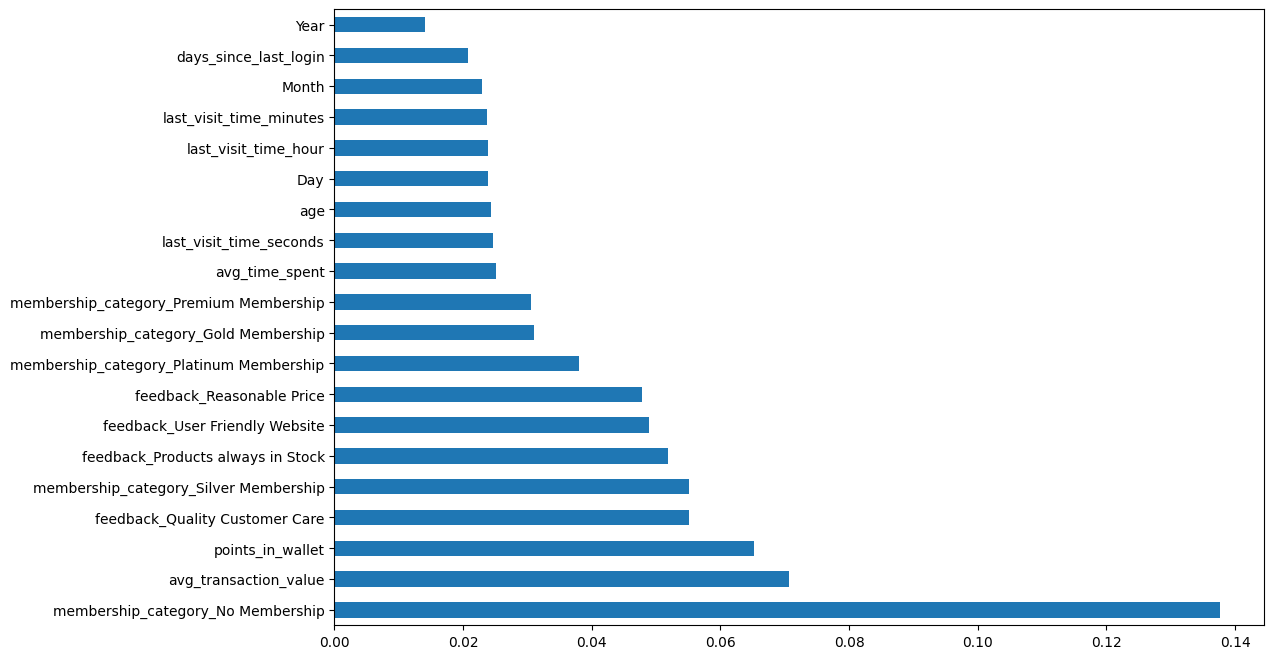

In [ ]:
# Plot graph of feature importances for better visualization

plt.figure(figsize = (12,8))
feat_importances = pd.Series(selection.feature_importances_,index=x.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

In [ ]:
# Model training

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)




In [ ]:
x_train.shape

(29593, 40)

In [ ]:
# Randomforest

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
# Checking training accuracy

print("training accuracy is :", rf.score(x_train, y_train)*100)

training accuracy is : 100.0


In [ ]:
# Checking accuracy of test dataset

print("testing accuracy is :", rf.score(x_test, y_test)*100)

testing accuracy is : 74.63170698743073


In [ ]:
# DecisionTree

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [ ]:
# Checking accuracy of test dataset

print("testing accuracy is :", model.score(x_test, y_test)*100)

testing accuracy is : 70.6446817137451


In [ ]:
# XGBoost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform y_train and y_test
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Get the number of classes from the encoded labels
num_classes = len(le.classes_)

xg = XGBClassifier(objective='multi:softmax', num_class=num_classes)
xg.fit(x_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=6, ...)

In [ ]:
# Checking accuracy of test dataset

print("testing accuracy is :", xg.score(x_test, y_test)*100)

testing accuracy is : 75.29395864305988


In [ ]:
# Hyperparameter tunning

from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {

         'learning_rate':[1,0.5,0.1,0.01],
         'max_depth':[3,5,10,20],
         'n_estimators':[10,50,100,200]

}

In [ ]:
grid = RandomizedSearchCV(XGBClassifier(objective='multi:softmax'), param_grid, verbose=3)

In [ ]:
grid.fit(x_train, y_train_encoded)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV 1/5] END learning_rate=0.1, max_depth=10, n_estimators=50;, score=0.755 total time=   4.7s
[CV 2/5] END learning_rate=0.1, max_depth=10, n_estimators=50;, score=0.763 total time=   2.1s
[CV 3/5] END learning_rate=0.1, max_depth=10, n_estimators=50;, score=0.753 total time=   2.1s
[CV 4/5] END learning_rate=0.1, max_depth=10, n_estimators=50;, score=0.757 total time=   2.7s
[CV 5/5] END learning_rate=0.1, max_depth=10, n_estimators=50;, score=0.756 total time=   3.2s
[CV 1/5] END learning_rate=1, max_depth=20, n_estimators=10;, score=0.741 total time=   2.0s
[CV 2/5] END learning_rate=1, max_depth=20, n_estimators=10;, score=0.738 total time=   1.1s
[CV 3/5] END learning_rate=1, max_depth=20, n_estimators=10;, score=0.743 total time=   1.1s
[CV 4/5] END learning_rate=1, max_depth=20, n_estimators=10;, score=0.742 total time=   1.1s
[CV 5/5] END learning_rate=1, max_depth=20, n_estimators=10;, score=0.744 total time=   1.1s

RandomizedSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=No...
                                           max_cat_threshold=None,
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [1, 0.5, 0.1, 0.01],
                                        'max_depth': [3, 5, 10, 20],
                                        'n_estimators': [10, 50, 100, 200]},
                   verbose=3)

In [ ]:
grid.best_params_

{'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}

In [ ]:
xg = XGBClassifier(n_estimators = 100, max_depth = 3, learning_rate = 0.1)
xg.fit(x_train, y_train_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
print("testing accuracy is :", xg.score(x_test, y_test)*100)

testing accuracy is : 75.57778078118665


In [ ]:
# Save Model

import pickle
file = 'xgboost_model.pkl'
pickle.dump(xg, open(file, 'wb'))

In [ ]:
load_model = pickle.load(open(file, 'rb'))

In [ ]:
y_pred = load_model.predict(x_test)


In [ ]:
y_pred

array([1, 4, 5, ..., 3, 3, 4])

In [ ]:
y_pred[8]

np.int64(5)